In [1]:
pip install --upgrade datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 15.0 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [1]:
token = "hf_REDACTED"
from huggingface_hub import login
login(token)

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM
import torch

model_id = "cerebras/btlm-3b-8k-base"
tokenizer = AutoTokenizer.from_pretrained(model_id, token=token)
model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto", torch_dtype=torch.float16)


tokenizer_config.json:   0%|          | 0.00/234 [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

...

The repository cerebras/btlm-3b-8k-base contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/cerebras/btlm-3b-8k-base .
 You can inspect the repository content at https://hf.co/cerebras/btlm-3b-8k-base.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


modeling_btlm.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/cerebras/btlm-3b-8k-base:
- modeling_btlm.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/5.29G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]



```
# This is formatted as code
```

<h1><b>Sentiment Analysis</b></h1>

---
Dataset : IMDB ,
Totall Samples : 1000

In [3]:
def batch_zero_shot_prompt(review):
    return f"""You are a sentiment analysis expert.

Review: "{review[0]}"

What is the sentiment of movie review above.Choose only one of the following:
- Positive
- Negative

Respond with one word only:

Answer:"""

In [4]:
import re
def extract_sentiment(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(Positive|Negative)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [5]:
from datasets import load_dataset

# Load the IMDb test subset
dataset = load_dataset("imdb", split="test")
shuffled_dataset = dataset.shuffle(seed=42)

Samples = shuffled_dataset.select(range(1000))

# IMDb labels: 0 = negative, 1 = positive
label_counts = {"positive": 0, "negative": 0}

# Count positive and negative labels
for example in Samples:
    label = example["label"]
    if label == 1:
        label_counts["positive"] += 1
    else:
        label_counts["negative"] += 1

print("Total reviews:", len(dataset))
print("Positive reviews:", label_counts["positive"])
print("Negative reviews:", label_counts["negative"])


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Total reviews: 25000
Positive reviews: 488
Negative reviews: 512


In [6]:
texts = []
true_labels = []
for i in range (0,len(Samples['text'])):
    texts.append(Samples['text'][i])
for i in range (0,len(Samples['text'])):
    true_labels.append(Samples['label'][i])
print(Samples)
print(len(texts))
print(len(true_labels))

Dataset({
    features: ['text', 'label'],
    num_rows: 1000
})
1000
1000


In [7]:
pip install codecarbon

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.7/358.7 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 74.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.5/92.5 kB 9.1 MB/s eta 0:00:00
  Attempting uninstall: psutil
    Found existing installation: psutil 5.9.5
    Uninstalling psutil-5.9.5:
      Successfully uninstalled psutil-5.9.5
  Attempting uninstall: httpx
    Found existing installation: httpx 0.28.1
    Uninstalling httpx-0.28.1:
      Successfully uninstalled httpx-0.28.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-genai 1.60.0 requires httpx<1.0.0,>=0.28.1, but you have httpx 0.27.2 which is incompatible.
firebase-admin 6.9.0 require

In [8]:
from codecarbon import EmissionsTracker

tracker = EmissionsTracker(
    project_name="phi4-imdb-inference",
    output_dir=".",          # where the CSV will be saved
    tracking_mode="process", # tracks CPU/GPU for this process only
    measure_power_secs=5,
    log_level="error"
)


[codecarbon WARNING @ 19:17:49] Multiple instances of codecarbon are allowed to run at the same time.


In [11]:
batch_size = 1
predicted_labels = []

tracker.start()

for i in range(0, len(Samples), batch_size):
    batch = Samples[i:i+batch_size]["text"]
    # print(f"=== Batch {i//batch_size + 1} ===")
    prompt = batch_zero_shot_prompt(batch)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
    output = model.generate(**inputs, max_new_tokens=5, use_cache=False)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    # print(decoded)
    prediction = extract_sentiment(decoded)
    predicted_labels.append(prediction)

emissions = tracker.stop()

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

In [13]:
inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
output = model.generate(**inputs, max_new_tokens=10, use_cache=False, eos_token_id=tokenizer.eos_token_id, early_stopping=True)
decoded = tokenizer.decode(output[0], skip_special_tokens=True)
print(decoded)

The following generation flags are not valid and may be ignored: ['early_stopping']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


You are a sentiment analysis expert.

Review: "This is the best version of Gypsy that has been filmed.Bette Midler is simply superb as Mama Rose.She has the voice,the gestures,the look,and most of all,a supreme acting ability to carry the role off and to make her character come alive.Her singing is,simply put:MAGNIFICENT! She especially shines in two numbers-"Everything's Coming Up Roses" and "Rose's Turn". The other actors are also fine,particularly Christine Ebersoll as Tessie.Also good is Peter Riegert;his portrayal of Herbie is acted with great style and believability.The direction of this movie is very,very good.There isn't a false note or gaffe in the entire production.This film is a vast improvement over the Roz Russell version filmed in 1962.Since viewing it again,I can state that the three greatest Mama Roses are:Ethel Merman,Bette Midler,and Angela Lansbury. See this movie.You'll be glad that you did."

What is the sentiment of movie review above.Choose only one of the follow

In [14]:
# Map predictions to 0/1
predictions = [1 if s == "Positive" else 0 for s in predicted_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions)
recall = recall_score(true_labels, predictions)
precision = precision_score(true_labels, predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)



Accuracy: 0.529
F1 Score: 0.5440464666021297
Recall: 0.5758196721311475
Precision: 0.5155963302752293


In [15]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 50
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : phi4-imdb-inference
Duration (s)           : 831.38

--- Energy ---
Total energy (kWh)     : 0.026894
Energy per sample (J)  : 1936.38
Energy per 1k samples (kJ): 1.94

--- Carbon ---
CO₂ emissions (kg)     : 0.003732
CO₂ per sample (g)     : 0.0746

--- Time ---
Avg time per sample (s): 16.628

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.20GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : United States
Cloud provider         : nan
Tracking mode          : process




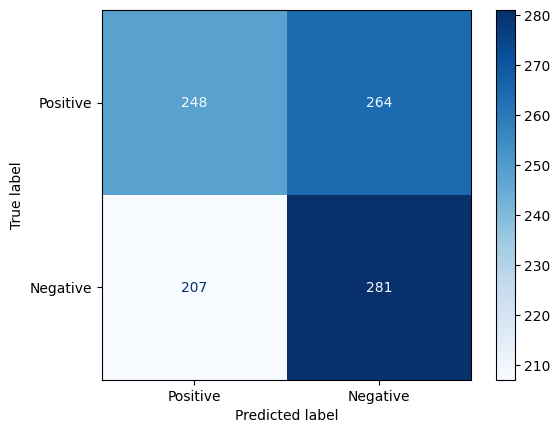

In [16]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Positive", "Negative"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

<h1><b>Hate Speech Detection</b></h1>

---
Dataset : OLID ,
Totall Samples : 400



In [17]:
from datasets import load_dataset

dataset = load_dataset("christophsonntag/OLID", split="test")
dataset[5]


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/13240 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/860 [00:00<?, ? examples/s]

{'id': 83681,
 'tweet': '. . . What the fuck did he do this time?',
 'cleaned_tweet': 'fuck time',
 'subtask_a': 'OFF',
 'subtask_b': 'TIN',
 'subtask_c': 'IND'}

In [18]:
dataset

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 860
})

In [19]:
shuffled_dataset = dataset.shuffle(seed=42).select(range(800))

shuffled_dataset

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 800
})

In [20]:
negatives = shuffled_dataset.filter(lambda x: x['subtask_a'] == 'OFF').select(range(200))
positives = shuffled_dataset.filter(lambda x: x['subtask_a'] == 'NOT').select(range(200))

# Combine both subsets
from datasets import concatenate_datasets
Samples = concatenate_datasets([negatives, positives])

Filter:   0%|          | 0/800 [00:00<?, ? examples/s]

Filter:   0%|          | 0/800 [00:00<?, ? examples/s]

In [21]:
Samples = Samples.shuffle()

In [22]:
label_counts = {"OFF": 0, "NOT": 0}

# Count positive and negative labels
for example in Samples:
    label = example["subtask_a"]
    if label == 'OFF':
        label_counts["OFF"] += 1
    else:
        label_counts["NOT"] += 1

print("Total tweets:", len(Samples))
print("Offensive tweets:", label_counts["OFF"])
print("Non-offensive tweets:", label_counts["NOT"])

Total tweets: 400
Offensive tweets: 200
Non-offensive tweets: 200


In [23]:
tweets = []
true_labels = []
for i in range (0,len(Samples['tweet'])):
    tweets.append(Samples['cleaned_tweet'][i])
for i in range (0,len(Samples['tweet'])):
    true_labels.append(Samples['subtask_a'][i])
print(Samples)
print(len(tweets))
print(len(true_labels))

Dataset({
    features: ['id', 'tweet', 'cleaned_tweet', 'subtask_a', 'subtask_b', 'subtask_c'],
    num_rows: 400
})
400
400


In [24]:
tweets[0]

'theview stormy trapped dollar bill face poor pornstar worries democratic party leader'

In [25]:
def batch_zero_shot_prompt(review):
    return f"""Read this tweet below :

Tweet: "{review[0]}"

Now tell me if the tweet is :
- Offensive
- Non-offensive

Answer in one word only.

Answer:
"""


In [26]:
import re
def extract_detection(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(Offensive|Non-offensive)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [28]:
batch_size = 1
predicted_labels = []

for i in range(0, len(Samples['tweet']), batch_size):
    batch = Samples[i:i+batch_size]["tweet"]
    # print(f"=== Batch {i//batch_size + 1} ===")
    prompt = batch_zero_shot_prompt(batch)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True,max_length=512).to(model.device)
    output = model.generate(**inputs, max_new_tokens=5,eos_token_id=tokenizer.eos_token_id,early_stopping=True, use_cache=False)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    # print(decoded)
    prediction = extract_detection(decoded)
    predicted_labels.append(prediction)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

In [29]:
# Map predictions to 0/1
predictions = [1 if s == "Offensive" else 0 for s in predicted_labels]
actual = [1 if s == 'OFF' else 0 for s in true_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(actual, predictions)
f1 = f1_score(actual, predictions)
recall = recall_score(actual, predictions)
precision = precision_score(actual, predictions)

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)


Accuracy: 0.5025
F1 Score: 0.18775510204081633
Recall: 0.115
Precision: 0.5111111111111111


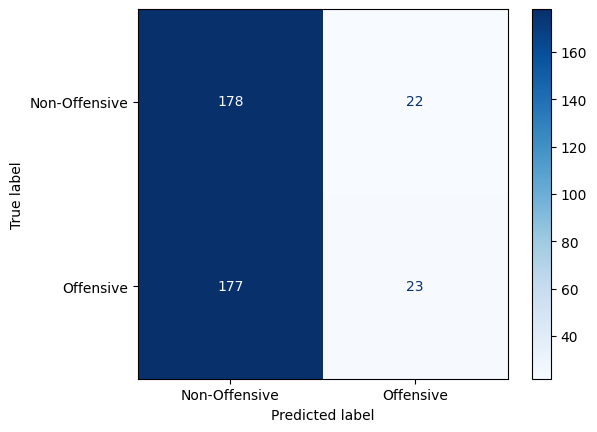

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(actual, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Offensive", "Offensive"])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [31]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 50
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : phi4-imdb-inference
Duration (s)           : 831.38

--- Energy ---
Total energy (kWh)     : 0.026894
Energy per sample (J)  : 1936.38
Energy per 1k samples (kJ): 1.94

--- Carbon ---
CO₂ emissions (kg)     : 0.003732
CO₂ per sample (g)     : 0.0746

--- Time ---
Avg time per sample (s): 16.628

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.20GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : United States
Cloud provider         : nan
Tracking mode          : process




<h1><b>News Classification</b></h1>

---



In [32]:
from datasets import load_dataset
print("=== AG News ===")
ag_news = load_dataset("ag_news", split="test")
ag_news

=== AG News ===


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'label'],
    num_rows: 7600
})

In [33]:
ag_news.features['label']

ClassLabel(names=['World', 'Sports', 'Business', 'Sci/Tech'])

In [34]:
ag_news[4]

{'text': "Calif. Aims to Limit Farm-Related Smog (AP) AP - Southern California's smog-fighting agency went after emissions of the bovine variety Friday, adopting the nation's first rules to reduce air pollution from dairy cow manure.",
 'label': 3}

In [35]:
World = ag_news.filter(lambda x: x['label'] == 0).select(range(150))
Sports = ag_news.filter(lambda x: x['label'] == 1).select(range(150))
Business = ag_news.filter(lambda x: x['label'] == 2).select(range(150))
SciTech = ag_news.filter(lambda x: x['label'] == 3).select(range(150))

from datasets import concatenate_datasets
Samples = concatenate_datasets([World, Sports,Business,  SciTech])

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

Filter:   0%|          | 0/7600 [00:00<?, ? examples/s]

In [36]:
Samples[42]

{'text': 'Israelis OK new homes in West Bank A leaked Israeli plan to build 1,000 new Jewish settler homes in the West Bank yesterday sent Bush administration officials scrambling for a response in the sensitive period before November #39;s presidential election. ',
 'label': 0}

In [37]:
Samples = Samples.shuffle()

In [38]:
label_counts = {"World":0, "Sports": 0, "Business" :0, "Sci/Tech": 0}

# Count labels
for example in Samples:
    label = example["label"]
    if label == 0:
        label_counts["World"] += 1
    elif label == 1:
        label_counts["Sports"] += 1
    elif label == 2:
        label_counts["Business"] += 1
    else:
        label_counts["Sci/Tech"] += 1

print("Total :", len(Samples))
print("World:", label_counts["World"])
print("Sports:", label_counts["Sports"])
print("Business:", label_counts["Business"])
print("Sci/Tech", label_counts["Sci/Tech"])

Total : 600
World: 150
Sports: 150
Business: 150
Sci/Tech 150


In [39]:
news = []
true_labels = []
for example in Samples:
    emotion = example["text"]
    label = example["label"]
    news.append(emotion)
    true_labels.append(label)

print(Samples)
print(len(news))
print(len(true_labels))

Dataset({
    features: ['text', 'label'],
    num_rows: 600
})
600
600


In [40]:
print(Samples[300])
print(news[300])
print(true_labels[300])

{'text': 'Mich. Elephant Gets Therapy for Arthritis ROYAL OAK, Mich. - Like any patient, Wanda needs positive reinforcement to wrestle through her physical therapy...', 'label': 0}
Mich. Elephant Gets Therapy for Arthritis ROYAL OAK, Mich. - Like any patient, Wanda needs positive reinforcement to wrestle through her physical therapy...
0


In [41]:
def news_classification_prompt(article):
    return f"""You are an AI assistant trained to classify news articles based on their content.

Article: "{article[0]}"

Classify the article into one of the following categories:
- World
- Sports
- Business
- SciTech

Answer in one word only.

Answer:"""

In [42]:
import re
def extract_sentiment(response):
    """Extracts 'Positive' or 'Negative' from the response using regex"""
    matches = re.findall(r'(World|Sports|Business|SciTech)', response, re.IGNORECASE)
    return matches[-1].capitalize() if matches else "Unknown"

In [44]:
batch_size = 1
predicted_labels = []

for i in range(0, len(Samples), batch_size):
    batch= Samples[i:i+batch_size]["text"]
    # print(f"=== Batch {i//batch_size + 1} ===")
    prompt = news_classification_prompt(batch)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True).to(model.device)
    output = model.generate(**inputs, max_new_tokens=5,eos_token_id=tokenizer.eos_token_id,early_stopping=True, use_cache=False)
    decoded = tokenizer.decode(output[0], skip_special_tokens=True)
    # print(decoded)
    prediction = extract_sentiment(decoded)
    predicted_labels.append(prediction)

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end gene

In [45]:
# Map predictions to 0/1
label_map = {
    "World": 0,
    "Sports": 1,
    "Business": 2,
    "Scitech": 3
}

predictions = [label_map[s] for s in predicted_labels]

from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score

accuracy = accuracy_score(true_labels, predictions)
f1 = f1_score(true_labels, predictions, average='macro')
recall = recall_score(true_labels, predictions, average='macro')
precision = precision_score(true_labels, predictions, average='macro')

print("Accuracy:", accuracy)
print("F1 Score:", f1)
print("Recall:", recall)
print("Precision:", precision)


Accuracy: 0.6166666666666667
F1 Score: 0.6187789546444522
Recall: 0.6166666666666667
Precision: 0.6578032443867938


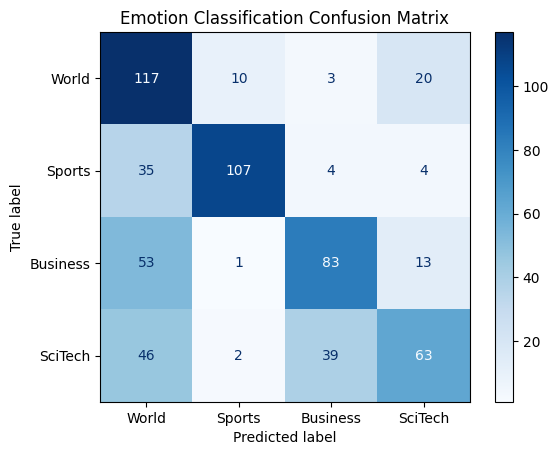

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(true_labels, predictions)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["World","Sports", "Business","SciTech"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Emotion Classification Confusion Matrix")
plt.show()

In [47]:
import pandas as pd

df = pd.read_csv("emissions.csv")
latest = df.iloc[-1]


NUM_SAMPLES= 50
print("\n========== CodeCarbon Summary ==========\n")

print(f"Project name           : {latest['project_name']}")
print(f"Duration (s)           : {latest['duration']:.2f}")

print("\n--- Energy ---")
print(f"Total energy (kWh)     : {latest['energy_consumed']:.6f}")
print(f"Energy per sample (J)  : {(latest['energy_consumed']/NUM_SAMPLES)*3.6e6:.2f}")
print(f"Energy per 1k samples (kJ): {(latest['energy_consumed']/NUM_SAMPLES)*3.6e3:.2f}")

print("\n--- Carbon ---")
print(f"CO₂ emissions (kg)     : {latest['emissions']:.6f}")
print(f"CO₂ per sample (g)     : {(latest['emissions']/NUM_SAMPLES)*1000:.4f}")

print("\n--- Time ---")
print(f"Avg time per sample (s): {latest['duration']/NUM_SAMPLES:.3f}")

print("\n--- Hardware ---")
print(f"CPU                    : {latest['cpu_model']}")
print(f"GPU                    : {latest['gpu_model']}")
print(f"RAM (GB)               : {latest['ram_total_size']}")

print("\n--- Environment ---")
print(f"Platform               : Google Colab")
print(f"Country (est.)         : {latest['country_name']}")
print(f"Cloud provider         : {latest['cloud_provider']}")
print(f"Tracking mode          : {latest['tracking_mode']}")

print("\n=======================================\n")



========== CodeCarbon Summary ==========

Project name           : phi4-imdb-inference
Duration (s)           : 831.38

--- Energy ---
Total energy (kWh)     : 0.026894
Energy per sample (J)  : 1936.38
Energy per 1k samples (kJ): 1.94

--- Carbon ---
CO₂ emissions (kg)     : 0.003732
CO₂ per sample (g)     : 0.0746

--- Time ---
Avg time per sample (s): 16.628

--- Hardware ---
CPU                    : Intel(R) Xeon(R) CPU @ 2.20GHz
GPU                    : 1 x Tesla T4
RAM (GB)               : 12.671436309814451

--- Environment ---
Platform               : Google Colab
Country (est.)         : United States
Cloud provider         : nan
Tracking mode          : process


